In [1]:
import numpy as np 
import pandas as pd    
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt   
%matplotlib inline 

In [2]:
df = pd.read_csv("cars-dataset.csv")
df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [4]:
# Q1: EDA & Preprocessing - Remove non-numeric entries from numeric columns
df = df.replace('?', np.nan)
mpg_df = df.dropna()

In [5]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null object
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 27.6+ KB


In [6]:
mpg_df['hp'] = mpg_df['hp'].astype('float64')

C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [7]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null float64
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 27.6+ KB


In [8]:
# Standardize Columns
from scipy.stats import zscore
numeric_cols = mpg_df.drop('car name', axis=1)
class_type  = mpg_df.pop("car name")
numeric_cols = numeric_cols.apply(zscore)
mpg_df = numeric_cols.join(class_type)   
mpg_df.head()

,cyl,disp,hp,wt,acc,yr,mpg,car name
0,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315,-0.698638,chevrolet chevelle malibu
1,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315,-1.083498,buick skylark 320
2,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315,-0.698638,plymouth satellite
3,1.483947,1.048584,1.184397,0.536845,-1.285258,-1.625315,-0.955212,amc rebel sst
4,1.483947,1.029447,0.924265,0.555706,-1.829655,-1.625315,-0.826925,ford torino


C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


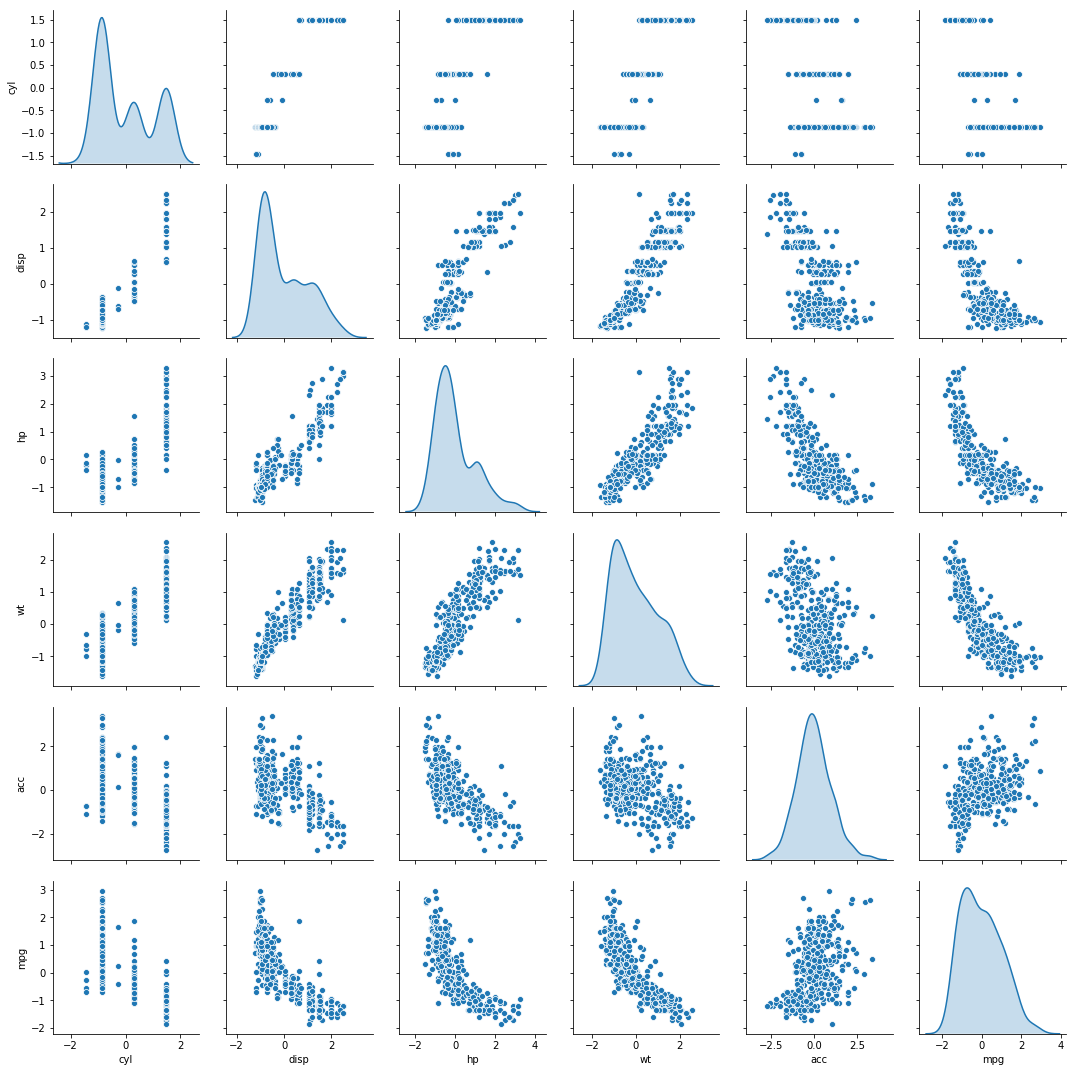

In [9]:
#Q2 - Pair Plot to visualize how the different variables are related
mpg_df_attr = mpg_df.loc[:,['cyl','disp','hp','wt','acc','mpg']]
sns.pairplot(mpg_df_attr,diag_kind='kde')

In [10]:
# Observation - Based on pairplot the observation is that there could potentially be around 3 to 4 clusters in the data.

In [11]:
#Q3 - KMeans clustering

In [12]:
cluster_range = range( 2, 6)   # expect 3 to 5 clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(mpg_df_attr)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,927.695464
1,3,596.524737
2,4,483.617036
3,5,416.494210


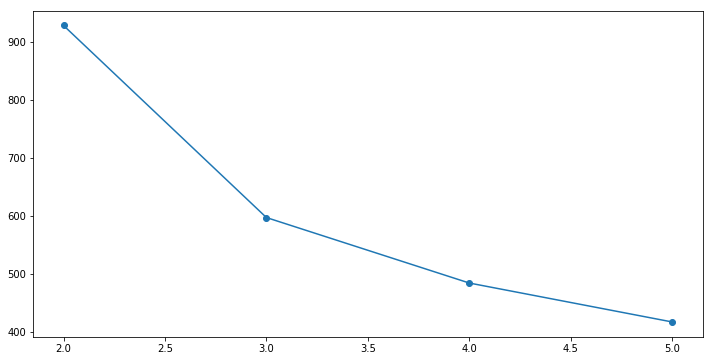

In [13]:
# Elbow plot
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [14]:
# The elbow plot confirms our visual analysis that there are likely 3 clusters
cluster = KMeans( n_clusters = 3, random_state = 2354 )
cluster.fit(mpg_df_attr)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=2354, tol=0.0001, verbose=0)

In [15]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.47184414,  1.46979213,  1.49145953,  1.37493755, -1.05253303,
        -1.14393843],
       [-0.86110766, -0.81098162, -0.6843036 , -0.79514908,  0.36356374,
         0.76382895],
       [ 0.33521362,  0.22847796, -0.06927147,  0.29302334,  0.30812718,
        -0.46592926]])

In [16]:
centroid_df = pd.DataFrame(centroids, columns = list(mpg_df_attr) )
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,1.471844,1.469792,1.491460,1.374938,-1.052533,-1.143938
1,-0.861108,-0.810982,-0.684304,-0.795149,0.363564,0.763829
2,0.335214,0.228478,-0.069271,0.293023,0.308127,-0.465929


In [17]:
# Separation of Clusters
prediction=cluster.predict(mpg_df_attr)
mpg_df_attr["CLUSTER"] = prediction  

In [18]:
mpg_df_attr.sample(n=6)

,cyl,disp,hp,wt,acc,mpg,CLUSTER
344,-0.864014,-1.037332,-1.052738,-1.299729,0.311639,1.995380,1
127,0.309967,0.359658,-0.116263,-0.090278,0.166467,-0.570352,2
79,-0.864014,-0.941647,-0.922672,-0.929585,0.892329,0.327654,1
75,1.483947,1.182542,1.184397,1.295994,-0.559396,-1.211785,0
184,-0.864014,-0.520637,-0.324369,-0.478104,-0.232757,0.199368,1
53,-0.864014,-1.180858,-1.026725,-1.419967,1.255261,0.969088,1


In [19]:
mpg_df_attr.groupby("CLUSTER").count()

,cyl,disp,hp,wt,acc,mpg
CLUSTER,,,,,,
0,97,97,97,97,97,97
1,202,202,202,202,202,202
2,93,93,93,93,93,93


In [20]:
mpg_df_grp0 = mpg_df_attr[mpg_df_attr['CLUSTER']==0]
mpg_df_grp1 = mpg_df_attr[mpg_df_attr['CLUSTER']==1]
mpg_df_grp2 = mpg_df_attr[mpg_df_attr['CLUSTER']==2]

In [21]:
print(mpg_df_grp0.shape)
print(mpg_df_grp1.shape)
print(mpg_df_grp2.shape)

(97, 7)
(202, 7)
(93, 7)


In [22]:
#Q4 - Use linear regression model on different clusters separately and print the coefficients
from sklearn.model_selection import train_test_split

In [23]:
# Copy all the predictor variables into X dataframe from CLUSTER-0.
X = mpg_df_grp0.drop(['mpg','CLUSTER'], axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = mpg_df_grp0[['mpg']]
# Split X and y into training and test set in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
rm = LinearRegression()
rm.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [24]:
# Print coefficients for each of the independent attributes for CLUSTER-0
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, rm.coef_[0][idx]))

The coefficient for cyl is -0.38757514644138436
The coefficient for disp is 0.14394569315468972
The coefficient for hp is -0.25241933289737556
The coefficient for wt is -0.19499801264908156
The coefficient for acc is -0.06731737158107935


In [25]:
# Copy all the predictor variables into X dataframe from CLUSTER-1.
X = mpg_df_grp1.drop(['mpg','CLUSTER'], axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = mpg_df_grp1[['mpg']]
# Split X and y into training and test set in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
rm = LinearRegression()
rm.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [26]:
# Print coefficients for each of the independent attributes for CLUSTER-1
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, rm.coef_[0][idx]))

The coefficient for cyl is 1.8214688290853938
The coefficient for disp is -0.6368919581110905
The coefficient for hp is -1.1721456841158981
The coefficient for wt is 0.02743210810063241
The coefficient for acc is -0.16509259359329767


In [27]:
# Copy all the predictor variables into X dataframe from CLUSTER-2.
X = mpg_df_grp2.drop(['mpg','CLUSTER'], axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = mpg_df_grp2[['mpg']]
# Split X and y into training and test set in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
rm = LinearRegression()
rm.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [28]:
# Print coefficients for each of the independent attributes for CLUSTER-2
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, rm.coef_[0][idx]))

The coefficient for cyl is 0.5035979531005041
The coefficient for disp is -0.4470390953126305
The coefficient for hp is 0.1190449492425498
The coefficient for wt is -0.30505917336459143
The coefficient for acc is -0.061124182822964154
